In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-25 15:36:46.979818


# Gaussian mixture model

GMM on a subset of the data as analysis strategy for separating signal and noise

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150
#sc.set_figure_params(scanpy=True)

warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [4]:
base_dir = Path("/home/workspace/projects/drg")
input_dir = base_dir / "data/h5ad/export_02/03_annotated"

### Read and process adata

In [5]:
adata = sc.read_h5ad(os.path.join(input_dir, 'ModelA_whole_all_annotated.h5ad'))
# have to use the version of the dataset that has the transgenes to draw positive and negative signal

bdata = sc.read_h5ad(os.path.join(input_dir, 'ModelB_whole_noTG_annotated.h5ad'))
# this is the dataset with adata.var subsetted to 475, 5 transgenes witheld

cdata = sc.read_h5ad(os.path.join(input_dir, 'ModelC_nuclear_all_annotated.h5ad')) #480 genes
ddata = sc.read_h5ad(os.path.join(input_dir, 'ModelD_nuclear_noTG_annotated.h5ad')) #474 genes, no transgenes

In [6]:
transgenes = ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']

In [7]:
adata.X = adata.layers['counts'].copy()
bdata.X = bdata.layers['counts'].copy()
cdata.X = cdata.layers['counts'].copy()
ddata.X = ddata.layers['counts'].copy()

In [8]:
adata.X[:5, :5].toarray()

array([[ 1., 21.,  0., 13.,  0.],
       [ 1., 49.,  0., 23.,  0.],
       [ 0., 22.,  0.,  6.,  0.],
       [ 0.,  1.,  0.,  0.,  0.],
       [ 0., 77.,  0.,  6.,  0.]], dtype=float32)

### view expression of each transgene -- set mappings based on adata, all cells, all genes

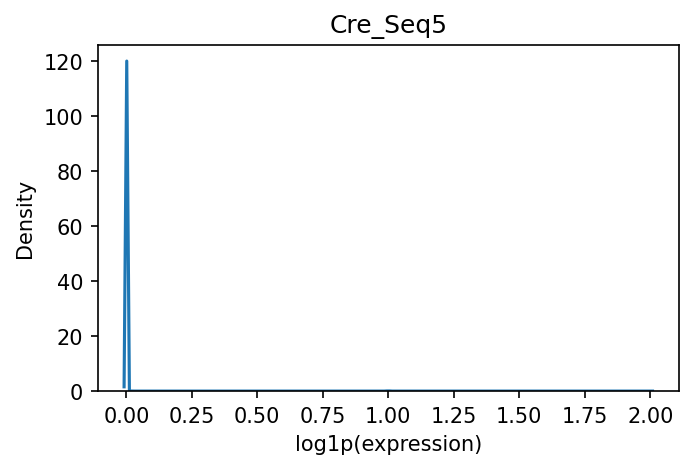

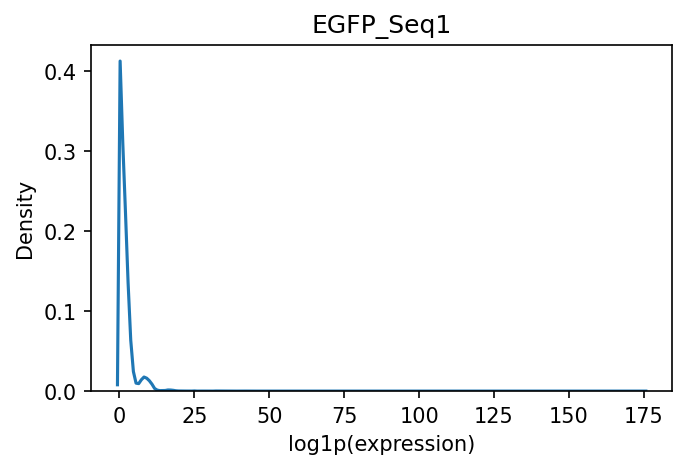

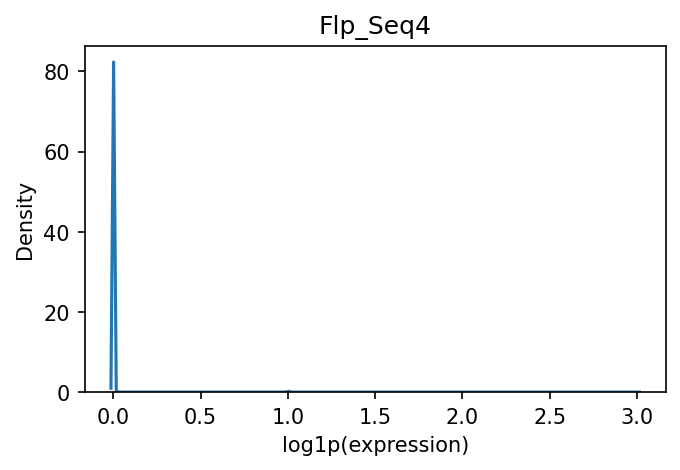

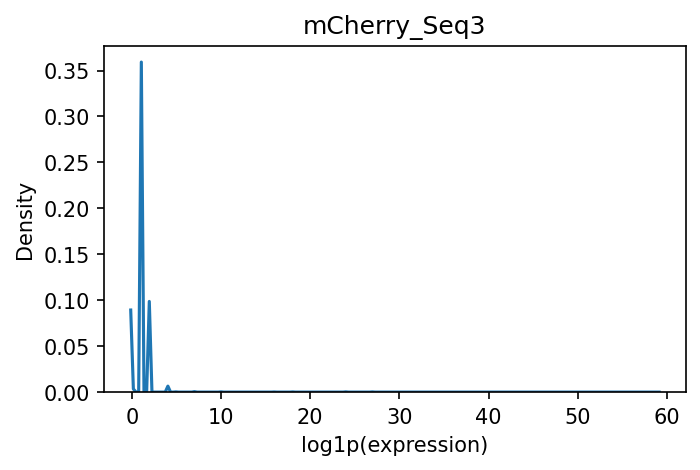

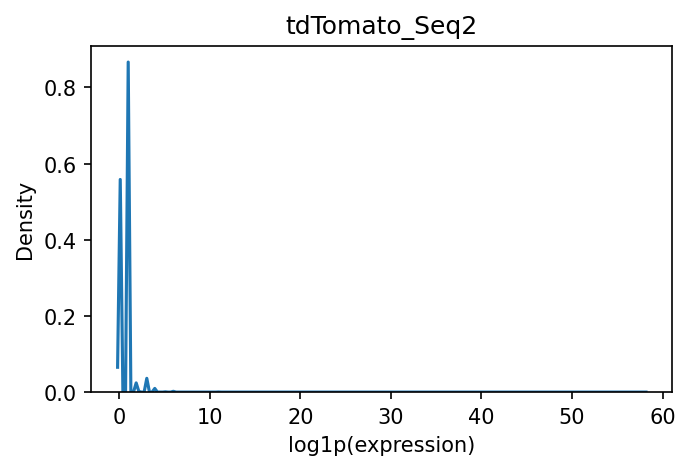

In [9]:
for g in transgenes:
    x = adata[:, g].X
    if hasattr(x, "toarray"): x = x.toarray().ravel()
    else: x = np.ravel(x)
    #x = np.log1p(x)   # log-transform
    
    plt.figure(figsize=(5,3))
    sns.kdeplot(x, bw_adjust=0.5)
    plt.title(g)
    plt.xlabel("log1p(expression)")
    plt.ylabel("Density")
    plt.show()

In [10]:
genes = ['EGFP_Seq1', 'tdTomato_Seq2']
n_components = 3
prob_threshold = 0.99
within_cluster_q = 0.99

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

gmm_results = {}

for g in genes:
    x = to_dense(adata[:, g].X)
    x_log = np.log1p(x).reshape(-1, 1)

    gmm = GaussianMixture(n_components=n_components, random_state=0).fit(x_log)
    probs = gmm.predict_proba(x_log)
    means = gmm.means_.flatten()
    high_cluster = np.argmax(means)

    high_mask = probs[:, high_cluster] > prob_threshold
    x_high = x[high_mask]

    thr_expr = np.percentile(x_high, within_cluster_q * 100) if x_high.size > 0 else np.expm1(means[high_cluster])
    hi_mask = high_mask & (x > thr_expr)

    adata.obs[f"{g}_hi"] = hi_mask

    # store all useful things for later plotting
    gmm_results[g] = {
        "gmm": gmm,
        "x": x,
        "x_log": x_log,
        "means": means,
        "covars": gmm.covariances_.flatten(),
        "weights": gmm.weights_.flatten(),
        "high_cluster": high_cluster,
        "high_mask": high_mask,
        "thr_expr": thr_expr,
    }

    print(f"{g}: high_cluster_mean={np.expm1(means[high_cluster]):.2f}, "
          f"thr={thr_expr:.2f}, n_hi={hi_mask.sum()} ({100*hi_mask.mean():.4f}%)")

adata.obs['EGFP_tdTomato_dual_hi'] = adata.obs['EGFP_Seq1_hi'] & adata.obs['tdTomato_Seq2_hi']
n_dual = adata.obs['EGFP_tdTomato_dual_hi'].sum()
print(f"\nUltra-strict dual positives: {n_dual}/{adata.n_obs} ({100*n_dual/adata.n_obs:.4f}%)")

EGFP_Seq1: high_cluster_mean=3.86, thr=16.00, n_hi=115 (0.3458%)
tdTomato_Seq2: high_cluster_mean=2.44, thr=14.73, n_hi=15 (0.0451%)

Ultra-strict dual positives: 2/33254 (0.0060%)


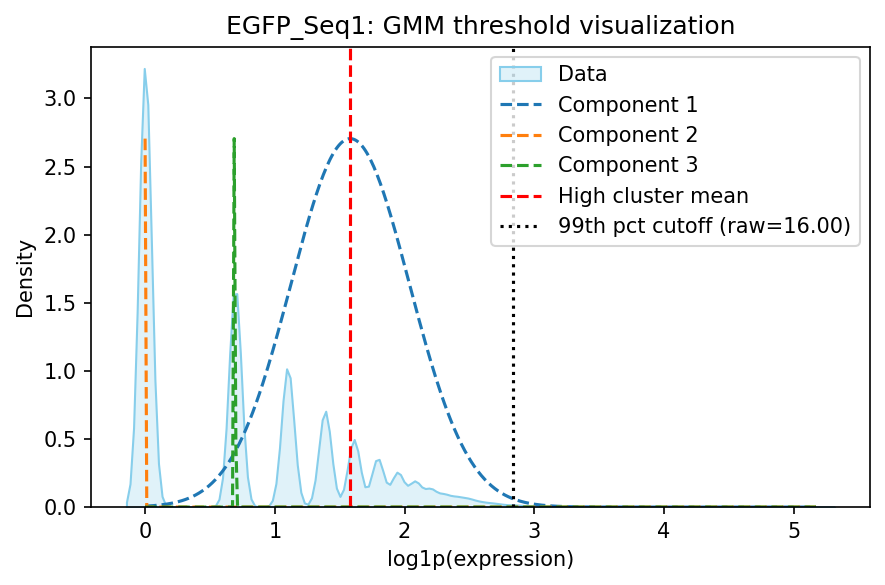

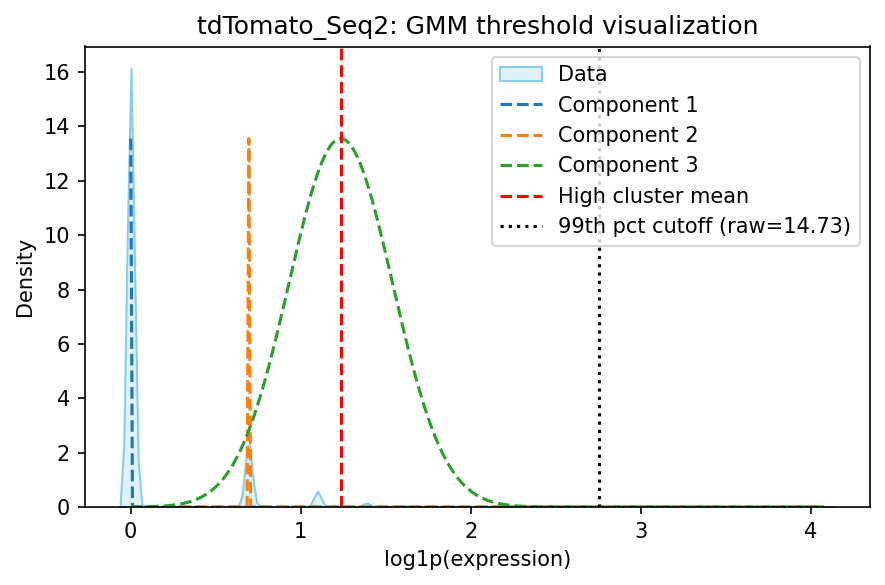

In [11]:
for g, res in gmm_results.items():
    x_log = res["x_log"]
    means = res["means"]
    covars = res["covars"]
    weights = res["weights"]
    high_cluster = res["high_cluster"]
    thr_expr = res["thr_expr"]

    # Convert thresholds for plotting
    mean_log = means[high_cluster]
    thr_log = np.log1p(thr_expr)

    # --- KDE of expression ---
    plt.figure(figsize=(6, 4))
    sns.kdeplot(x_log.ravel(), bw_adjust=0.5, fill=True, color="skyblue", label="Data")

    # --- Overlay Gaussian components ---
    xs = np.linspace(x_log.min(), x_log.max(), 400).reshape(-1, 1)
    total_pdf = np.zeros_like(xs)

    for i, (m, c, w) in enumerate(zip(means, covars, weights)):
        pdf = w * np.exp(-0.5 * ((xs - m) ** 2 / c)) / np.sqrt(2 * np.pi * c)
        total_pdf += pdf
        plt.plot(xs, pdf / pdf.max() * plt.ylim()[1] * 0.8, "--", label=f"Component {i+1}")

    # --- Mark key thresholds ---
    plt.axvline(mean_log, color="red", ls="--", label="High cluster mean")
    plt.axvline(thr_log, color="black", ls=":", label=f"99th pct cutoff (raw={thr_expr:.2f})")

    plt.title(f"{g}: GMM threshold visualization")
    plt.xlabel("log1p(expression)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

worth annotating single positive frequencies as well.

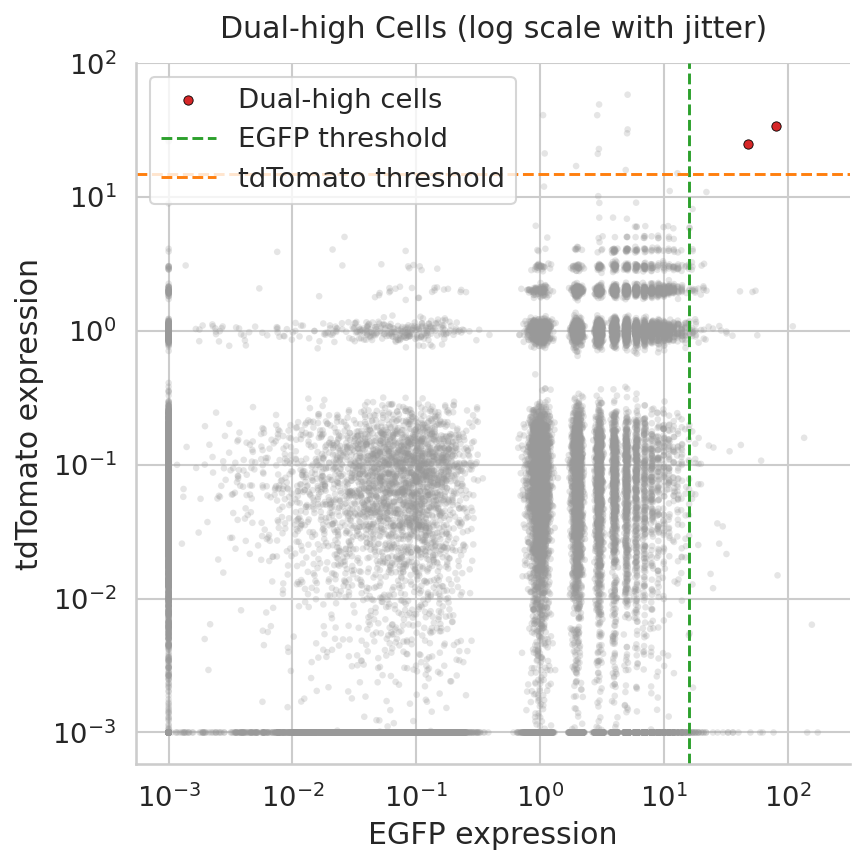

In [12]:
# thresholds
thr_egfp = gmm_results["EGFP_Seq1"]["thr_expr"]
thr_td   = gmm_results["tdTomato_Seq2"]["thr_expr"]

def to_dense(x):
    return x.toarray().ravel() if hasattr(x, "toarray") else np.ravel(x)

# extract expression
x_egfp = to_dense(adata[:, "EGFP_Seq1"].X)
x_td   = to_dense(adata[:, "tdTomato_Seq2"].X)
dual   = adata.obs['EGFP_tdTomato_dual_hi']

# jitter (small, positive)
rng = np.random.default_rng(0)
x_egfp_j = np.clip(x_egfp + rng.normal(scale=0.1, size=x_egfp.shape), 1e-3, None)
x_td_j   = np.clip(x_td   + rng.normal(scale=0.1, size=x_td.shape),   1e-3, None)

sns.set_theme(style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(figsize=(6,6))

# background points
ax.scatter(
    x_egfp_j, x_td_j, s=10,
    alpha=0.25, color="#999999", edgecolor="none"
)

# highlight dual-high cells
ax.scatter(
    x_egfp_j[dual], x_td_j[dual], 
    s=20, color="#d62728", edgecolor="black", linewidth=0.4,
    label="Dual-high cells"
)

# thresholds
ax.axvline(thr_egfp, color="#2ca02c", ls="--", lw=1.4, label="EGFP threshold")
ax.axhline(thr_td,   color="#ff7f0e", ls="--", lw=1.4, label="tdTomato threshold")

# scales + labels
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("EGFP expression")
ax.set_ylabel("tdTomato expression")
ax.set_title("Dual-high Cells (log scale with jitter)", pad=12)

# legend outside, cleaner
ax.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

### print barcodes

In [13]:
dual_positive_cells = adata.obs_names[adata.obs['EGFP_tdTomato_dual_hi']]
print("Dual-positive cell barcodes:")
print(list(dual_positive_cells))
print(f"\nTotal: {len(dual_positive_cells)} cells")

Dual-positive cell barcodes:
['aapmhgin-1-0', 'aefmnmje-1-2']

Total: 2 cells


### use barcodes to see wehre they are in bdata

In [18]:
dual_barcodes = ['aapmhgin-1-0', 'aefmnmje-1-2']

# Match by core portion of barcode
# Match by core portion of barcode
dual_core = {bc.split('-', 1)[0] for bc in dual_barcodes}

# Barcodes actually present in each dataset
dual_in_a = [obs for obs in adata.obs_names 
             if obs.split('-', 1)[0] in dual_core]
dual_in_b = [obs for obs in bdata.obs_names 
             if obs.split('-', 1)[0] in dual_core]
dual_in_c = [obs for obs in cdata.obs_names 
             if obs.split('-', 1)[0] in dual_core]
dual_in_d = [obs for obs in ddata.obs_names 
             if obs.split('-', 1)[0] in dual_core]

# Boolean masks for each dataset
dual_mask_a = adata.obs_names.isin(dual_in_b)  # use shared barcode set
dual_mask_b = bdata.obs_names.isin(dual_in_b)
dual_mask_c = cdata.obs_names.isin(dual_in_b)
dual_mask_d = ddata.obs_names.isin(dual_in_b)

print("Matched barcodes:", dual_in_b)
print("Counts:",
      len(dual_mask_a.nonzero()[0]),
      len(dual_mask_b.nonzero()[0]),
      len(dual_mask_c.nonzero()[0]),
      len(dual_mask_d.nonzero()[0]))

Matched barcodes: ['aapmhgin-1-0', 'aefmnmje-1-2']
Counts: 2 2 2 2


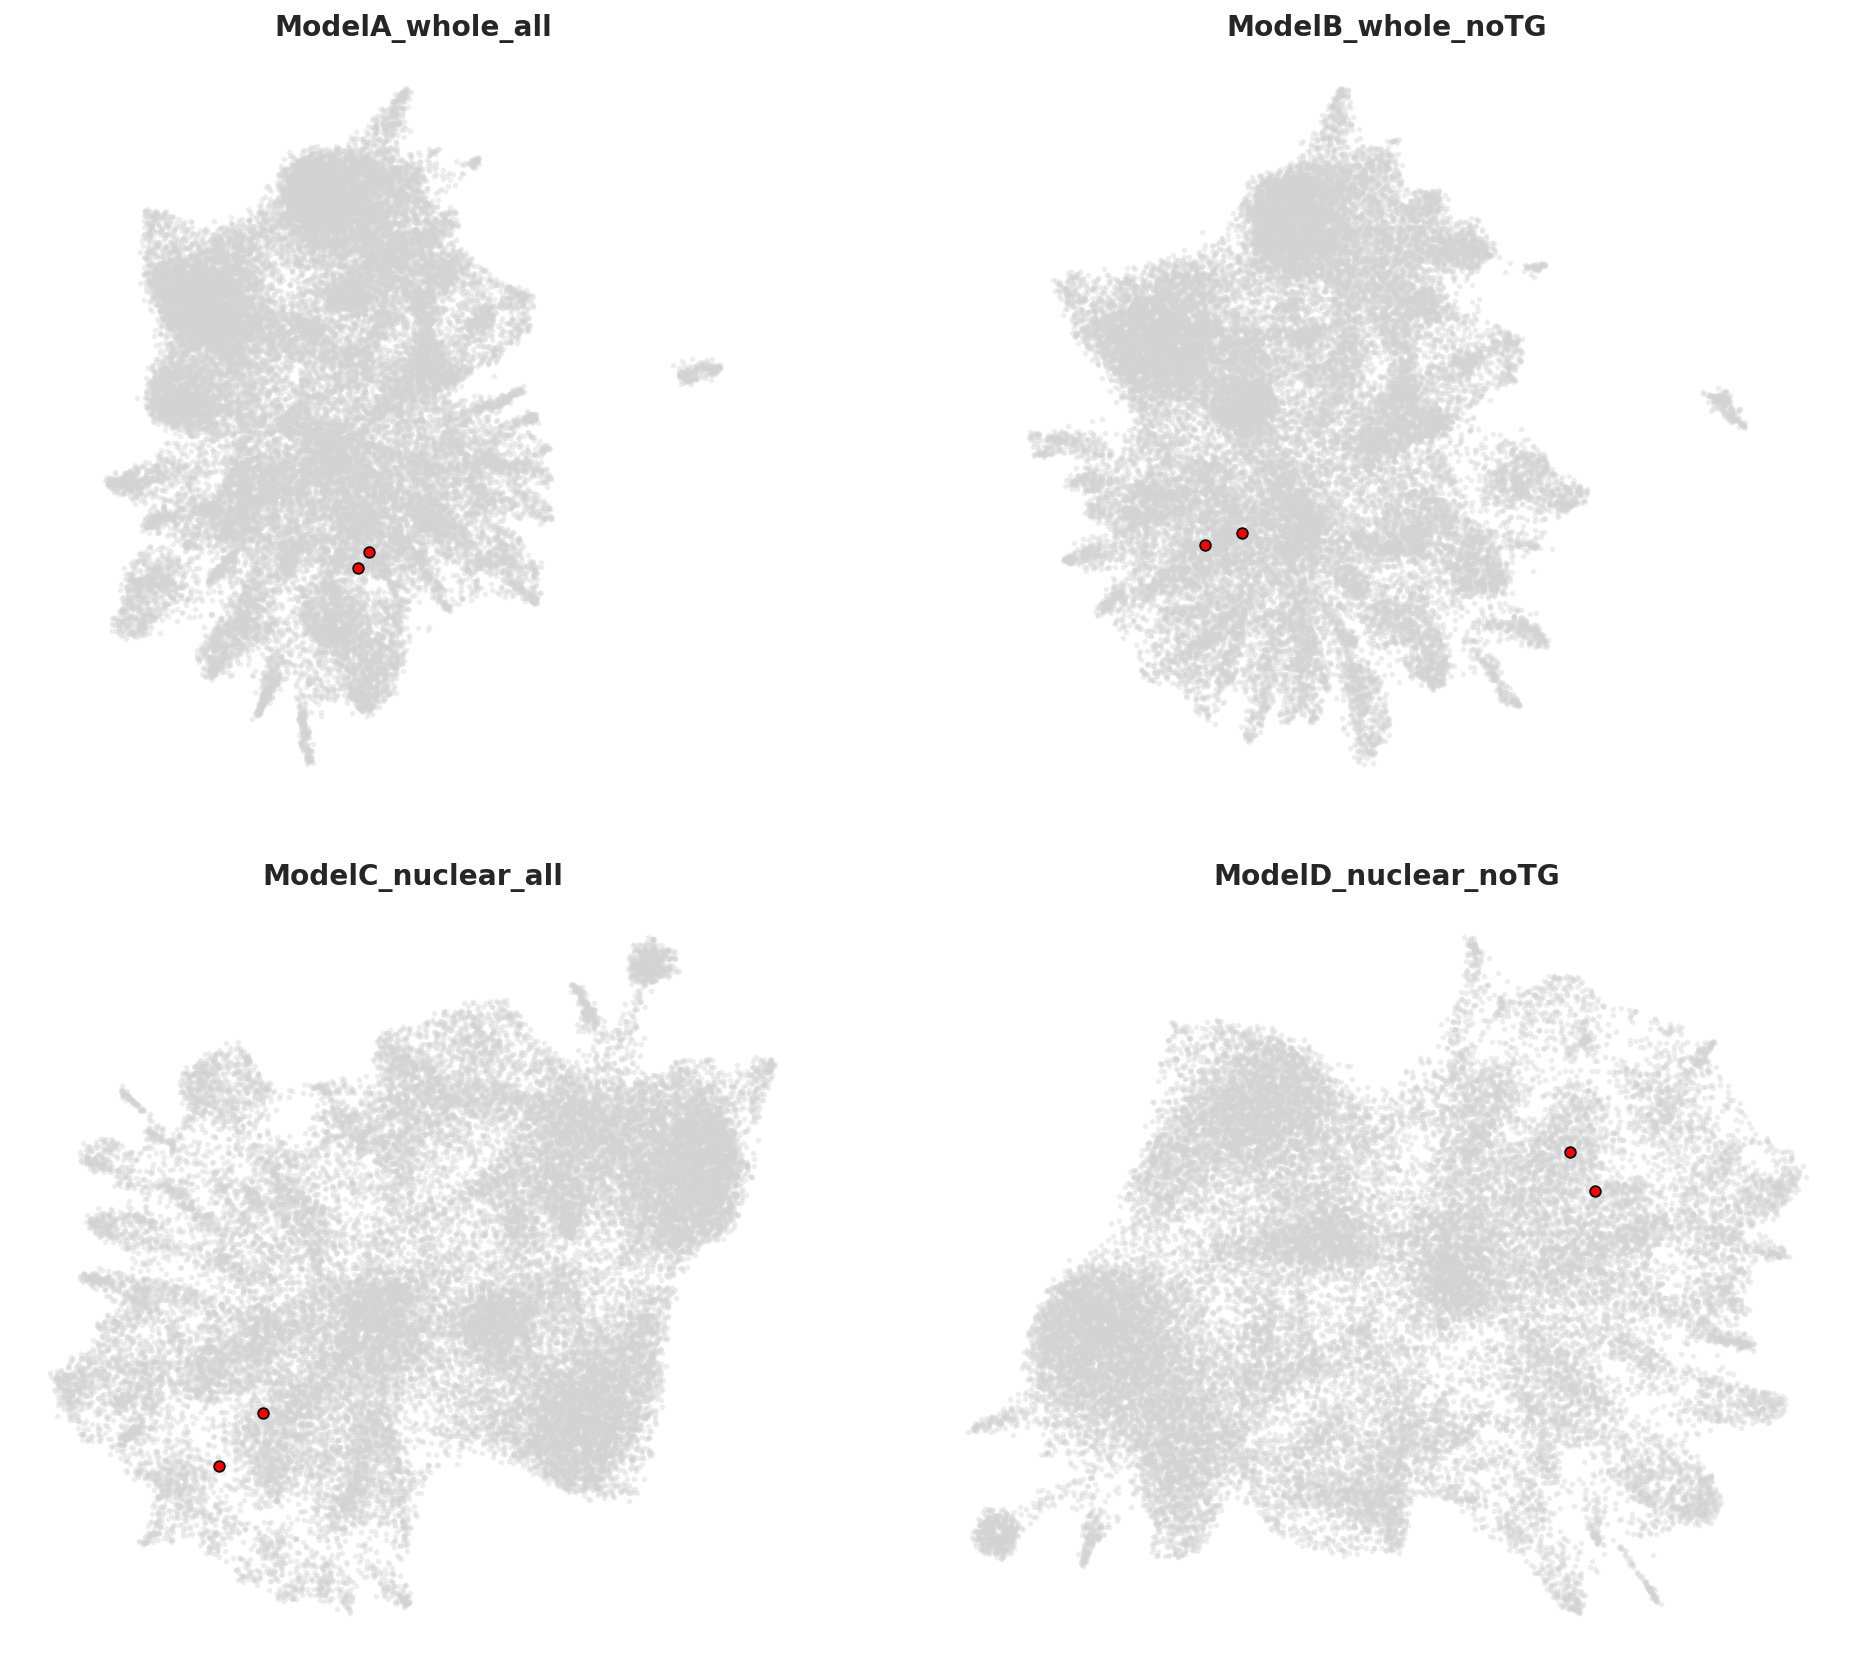

In [19]:
plt.rcParams.update({
    "font.size": 11,
    "axes.titleweight": "bold",
})

datasets = {
    "adata": adata,
    "bdata": bdata,
    "cdata": cdata,
    "ddata": ddata,
}

masks = {
    "adata": dual_mask_a,
    "bdata": dual_mask_b,
    "cdata": dual_mask_c,
    "ddata": dual_mask_d,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12), dpi=140)

# flatten axes for easy iteration
axes = axes.flatten()

for ax, name in zip(axes, datasets.keys()):
    
    ds = datasets[name]
    mask = masks[name]
    
    # Background cells
    ax.scatter(
        ds.obsm["X_umap"][:, 0],
        ds.obsm["X_umap"][:, 1],
        s=4, c="lightgray", alpha=0.28
    )
    
    # Dual-innervated cells
    ax.scatter(
        ds.obsm["X_umap"][mask, 0],
        ds.obsm["X_umap"][mask, 1],
        s=30,
        facecolors="red",
        edgecolors="black",
        linewidths=0.9
    )
    
    # Title: pull scvi_model name
    title = f"{name}"
    if "scvi_model" in ds.obs.columns:
        model_name = ds.obs["scvi_model"].unique()
        if len(model_name) == 1:
            title = model_name[0]
    
    ax.set_title(title, pad=10)

    # Clean up axes
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_aspect("equal", "box")

plt.tight_layout(w_pad=3, h_pad=3)
plt.show()

In [20]:
datasets = [adata, bdata, cdata, ddata]

print("\nCluster identities of barcoded cells:\n")

for ds in datasets:
    # Extract model name (each AnnData has only one)
    model_name = ds.obs["scvi_model"].unique()[0]
    print(f"{model_name}")

    # Extract clusters for the dual-positive cells
    barcodes = ds.obs_names[ds.obs_names.isin(dual_in_b)]
    clusters = ds.obs.loc[barcodes, "leiden_scVI_1"]

    for cell_id, clust in clusters.items():
        print(f"{cell_id}: cluster {clust}")
    print()


Cluster identities of barcoded cells:

ModelA_whole_all
aapmhgin-1-0: cluster 8
aefmnmje-1-2: cluster 8

ModelB_whole_noTG
aapmhgin-1-0: cluster 8
aefmnmje-1-2: cluster 8

ModelC_nuclear_all
aapmhgin-1-0: cluster 19
aefmnmje-1-2: cluster 6

ModelD_nuclear_noTG
aapmhgin-1-0: cluster 6
aefmnmje-1-2: cluster 6



## Session info

In [21]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter
